# Análise da População Brasileira — Censo 2010 vs Censo 2022

1. Instalação/importação das bibliotecas
2. Leitura da tabela original (IBGE)
3. Agregação da população por estado (UF)
4. Ordenação pelo crescimento populacional (2022 - 2010)
5. Exportação da tabela de estados em CSV
6. Análise por município (mesma lógica)
7. Exportação da tabela de municípios em CSV
8. Gráficos do crescimento populacional por estado


## 1. Instalação e importação das bibliotecas

In [1]:
# Caso alguma biblioteca não esteja instalada no seu ambiente, descomente a linha abaixo:
# %pip install pandas openpyxl matplotlib seaborn

import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.float_format", lambda x: f"{x:,.0f}")
sns.set_theme(style="whitegrid")


## 2. Leitura da tabela

A planilha do IBGE possui 3 linhas de cabeçalho/título antes da tabela de fato
(linhas de título do Censo e uma coluna vazia à esquerda). Por isso usamos
`header=2` (a 3ª linha, índice 2) e ignoramos a primeira coluna, que vem vazia.


In [2]:
caminho_arquivo = "dados/CD2022_Populacao_2010_Compatibilizada_20231222__1___3_.xlsx"

df = pd.read_excel(
    caminho_arquivo,
    sheet_name="Municípios",
    header=2,
)

# Remove a primeira coluna (vazia) e espaços/quebras de linha nos nomes das colunas
df = df.dropna(axis=1, how="all")
df.columns = [str(c).strip().replace("\n", " ") for c in df.columns]

print(df.shape)
df.head()


(5574, 7)


,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010 (Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022
0,RO,11,15,Alta Floresta D'Oeste,"24,392","24,392","21,494"
1,RO,11,23,Ariquemes,"90,353","90,353","96,833"
2,RO,11,31,Cabixi,"6,313","6,313","5,351"
3,RO,11,49,Cacoal,"78,574","78,574","86,887"
4,RO,11,56,Cerejeiras,"17,029","17,029","15,890"


In [3]:
df.columns.tolist()


['UF',
 'COD. UF',
 'COD. MUNIC',
 'NOME DO MUNICÍPIO',
 'População Município 2010 (Sinopse)',
 'População 2010 (Alterações de Limites até 2022)1',
 'População Censo 2022']

Vamos identificar as colunas de população de 2010 e de 2022. A planilha traz
duas colunas de 2010 (a "Sinopse" original e a versão "compatibilizada" com os
limites de 2022); usamos a **compatibilizada**, pois é a comparável com 2022.

In [4]:
col_2010 = [c for c in df.columns if "2010" in c and "Alterações" in c][0]
col_2022 = [c for c in df.columns if "Censo 2022" in c][0]

print("Coluna 2010 usada:", col_2010)
print("Coluna 2022 usada:", col_2022)

# Garante que as colunas de população sejam numéricas
df[col_2010] = pd.to_numeric(df[col_2010], errors="coerce")
df[col_2022] = pd.to_numeric(df[col_2022], errors="coerce")


Coluna 2010 usada: População 2010 (Alterações de Limites até 2022)1
Coluna 2022 usada: População Censo 2022


## 3. Tabela de população agregada por estado (UF)

In [5]:
pop_estado = (
    df.groupby(["COD. UF", "UF"], as_index=False)
      .agg(
          populacao_2010=(col_2010, "sum"),
          populacao_2022=(col_2022, "sum"),
      )
)

pop_estado.head()


,COD. UF,UF,populacao_2010,populacao_2022
0,11,RO,"1,562,409","1,581,196"
1,12,AC,"733,559","830,018"
2,13,AM,"3,483,985","3,941,613"
3,14,RR,"450,479","636,707"
4,15,PA,"7,581,051","8,120,131"


## 4. Ordenação pelo crescimento populacional (2022 - 2010)

In [6]:
pop_estado["crescimento_absoluto"] = pop_estado["populacao_2022"] - pop_estado["populacao_2010"]
pop_estado["crescimento_percentual"] = (
    pop_estado["crescimento_absoluto"] / pop_estado["populacao_2010"] * 100
).round(2)

pop_estado = pop_estado.sort_values("crescimento_absoluto", ascending=False).reset_index(drop=True)
pop_estado


,COD. UF,UF,populacao_2010,populacao_2022,crescimento_absoluto,crescimento_percentual
0,35,SP,"41,262,199","44,411,238","3,149,039",8
1,42,SC,"6,248,436","7,610,361","1,361,925",22
2,52,GO,"6,001,789","7,056,495","1,054,706",18
3,41,PR,"10,444,526","11,444,380","999,854",10
4,31,MG,"19,597,330","20,539,989","942,659",5
5,51,MT,"3,035,122","3,658,649","623,527",21
6,15,PA,"7,581,051","8,120,131","539,080",7
7,13,AM,"3,483,985","3,941,613","457,628",13
8,23,CE,"8,451,644","8,794,957","343,313",4
9,32,ES,"3,514,952","3,833,712","318,760",9


## 5. Exportação da tabela por estado em CSV

In [7]:
pop_estado.to_csv(r"saidas/populacao_por_estado.csv", sep=";", index=False, encoding="utf-8-sig")
print("Arquivo salvo em: saidas/populacao_por_estado.csv")


Arquivo salvo em: saidas/populacao_por_estado.csv


## 6. Tabela de população por município

In [8]:
pop_municipio = df[["COD. UF", "UF", "COD. MUNIC", "NOME DO MUNICÍPIO", col_2010, col_2022]].copy()
pop_municipio = pop_municipio.rename(columns={
    col_2010: "populacao_2010",
    col_2022: "populacao_2022",
})

pop_municipio.head()


,COD. UF,UF,COD. MUNIC,NOME DO MUNICÍPIO,populacao_2010,populacao_2022
0,11,RO,15,Alta Floresta D'Oeste,"24,392","21,494"
1,11,RO,23,Ariquemes,"90,353","96,833"
2,11,RO,31,Cabixi,"6,313","5,351"
3,11,RO,49,Cacoal,"78,574","86,887"
4,11,RO,56,Cerejeiras,"17,029","15,890"


## 7. Ordenação dos municípios pelo crescimento populacional

In [9]:
pop_municipio["crescimento_absoluto"] = pop_municipio["populacao_2022"] - pop_municipio["populacao_2010"]
pop_municipio["crescimento_percentual"] = (
    pop_municipio["crescimento_absoluto"] / pop_municipio["populacao_2010"] * 100
).round(2)

pop_municipio = pop_municipio.sort_values("crescimento_absoluto", ascending=False).reset_index(drop=True)
pop_municipio.head(20)


,COD. UF,UF,COD. MUNIC,NOME DO MUNICÍPIO,populacao_2010,populacao_2022,crescimento_absoluto,crescimento_percentual
0,13,AM,"2,603",Manaus,"1,802,014","2,063,689","261,675",15
1,53,DF,108,Brasília,"2,572,159","2,817,381","245,222",10
2,35,SP,"50,308",São Paulo,"11,253,503","11,451,999","198,496",2
3,35,SP,"52,205",Sorocaba,"586,816","723,682","136,866",23
4,52,GO,"8,707",Goiânia,"1,301,912","1,437,366","135,454",10
5,14,RR,100,Boa Vista,"284,313","413,486","129,173",45
6,42,SC,"5,407",Florianópolis,"421,240","537,211","115,971",28
7,15,PA,"5,536",Parauapebas,"153,908","267,836","113,928",74
8,50,MS,"2,704",Campo Grande,"786,774","898,100","111,326",14
9,25,PB,"7,507",João Pessoa,"723,515","833,932","110,417",15


## 8. Exportação da tabela por município em CSV

In [10]:
pop_municipio.to_csv(r"saidas/populacao_por_municipio.csv", sep=";", index=False, encoding="utf-8-sig")
print("Arquivo salvo em: saidas/populacao_por_municipio.csv")


Arquivo salvo em: saidas/populacao_por_municipio.csv


## 9. Gráficos — crescimento populacional por estado

### 9.1 Barras agrupadas: população 2010 x 2022 (10 UFs com maior crescimento absoluto)

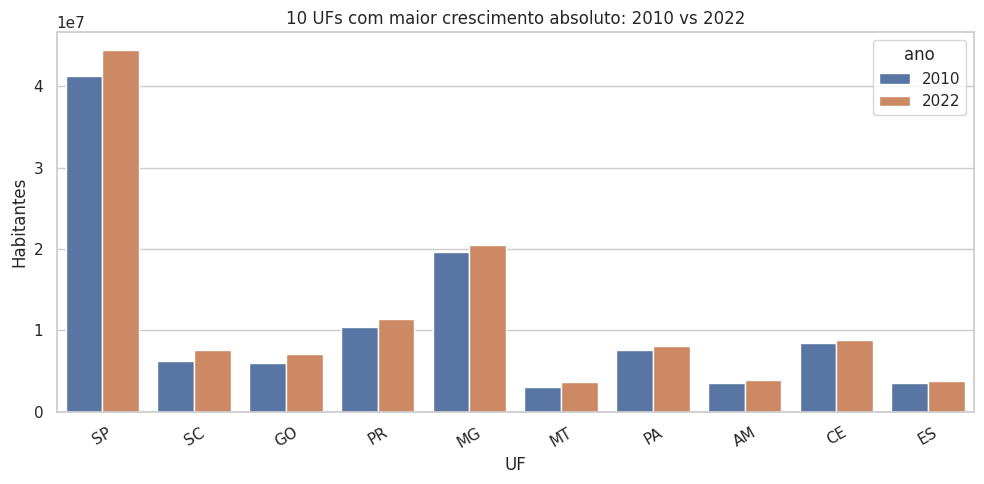

In [11]:
top10_estados = pop_estado.head(10)

top_melt = top10_estados.melt(
    id_vars="UF",
    value_vars=["populacao_2010", "populacao_2022"],
    var_name="ano",
    value_name="populacao",
)
top_melt["ano"] = top_melt["ano"].map({
    "populacao_2010": "2010",
    "populacao_2022": "2022",
})

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top_melt, x="UF", y="populacao", hue="ano", ax=ax)
ax.set_title("10 UFs com maior crescimento absoluto: 2010 vs 2022")
ax.set_xlabel("UF")
ax.set_ylabel("Habitantes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("saidas/grafico_top10_uf_2010_vs_2022.png", dpi=150)
plt.show()


### 9.2 Crescimento absoluto por estado (todas as UFs)

/tmp/ipykernel_556/512604349.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pop_estado, x="UF", y="crescimento_absoluto", palette=cores, ax=ax)


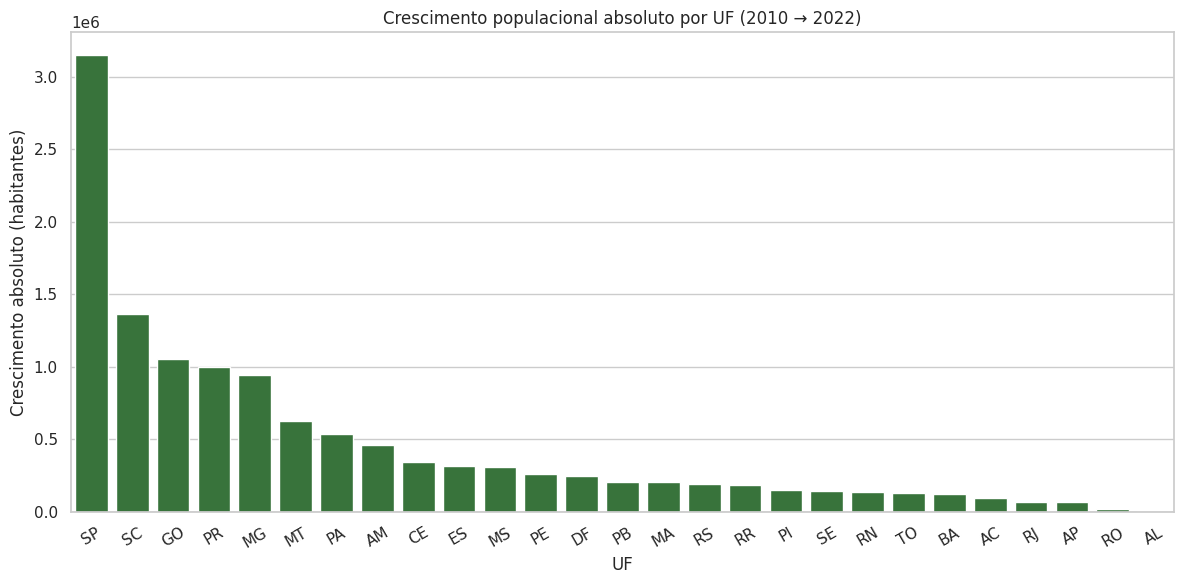

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
cores = ["#2e7d32" if v >= 0 else "#c62828" for v in pop_estado["crescimento_absoluto"]]
sns.barplot(data=pop_estado, x="UF", y="crescimento_absoluto", palette=cores, ax=ax)
ax.set_title("Crescimento populacional absoluto por UF (2010 → 2022)")
ax.set_xlabel("UF")
ax.set_ylabel("Crescimento absoluto (habitantes)")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("saidas/grafico_crescimento_absoluto_por_uf.png", dpi=150)
plt.show()


### 9.3 Crescimento percentual por estado (todas as UFs)

/tmp/ipykernel_556/3399059052.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pop_estado_pct, x="UF", y="crescimento_percentual", palette=cores, ax=ax)


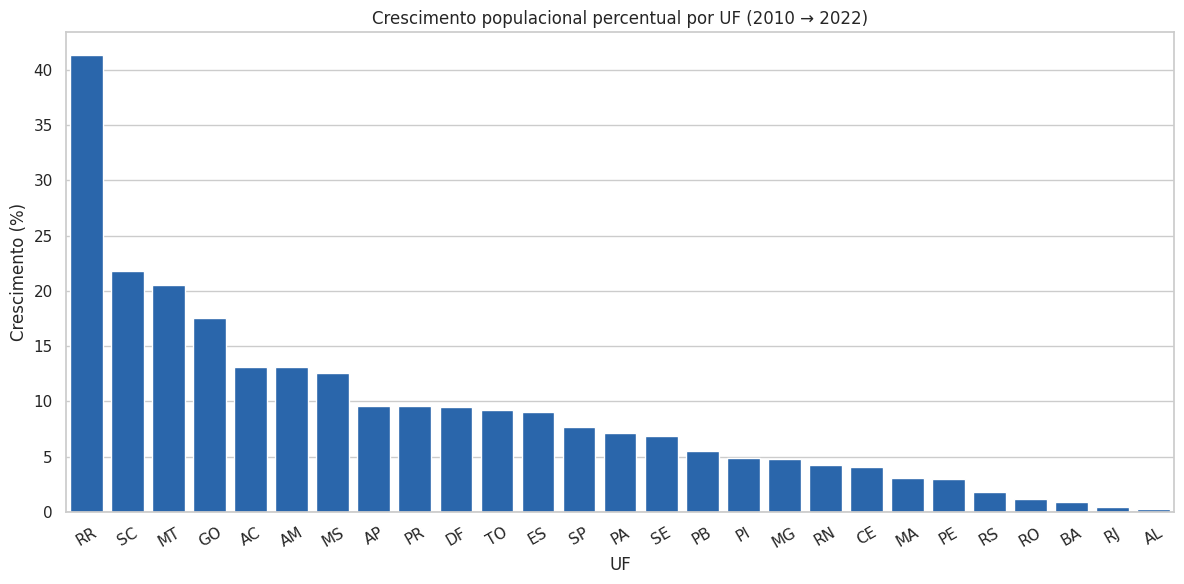

In [13]:
pop_estado_pct = pop_estado.sort_values("crescimento_percentual", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
cores = ["#1565c0" if v >= 0 else "#c62828" for v in pop_estado_pct["crescimento_percentual"]]
sns.barplot(data=pop_estado_pct, x="UF", y="crescimento_percentual", palette=cores, ax=ax)
ax.set_title("Crescimento populacional percentual por UF (2010 → 2022)")
ax.set_xlabel("UF")
ax.set_ylabel("Crescimento (%)")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("saidas/grafico_crescimento_percentual_por_uf.png", dpi=150)
plt.show()


## 10. Conclusão

- As tabelas agregadas (`populacao_por_estado.csv`) e por município
  (`populacao_por_municipio.csv`) foram salvas na pasta `saidas/`.
- Os gráficos também foram salvos como PNG na pasta `saidas/`.
- A UF com maior crescimento **absoluto** aparece no topo de `pop_estado`; a UF
  com maior crescimento **percentual** aparece no topo de `pop_estado_pct`.
